# Laboratorio 4 — Simulación de eventos discretos
## 5.3 Modelo de inventario probabilístico (Sec. 5.6 de Rios08)

Simulación de sucesos discretos de un almacén con política de revisión continua $(p, P)$:

* Los clientes llegan según un proceso de Poisson de parámetro $\lambda$ y cada uno demanda una cantidad
  aleatoria $D$ del producto. Si hay inventario suficiente se le vende toda su demanda a $r$ por unidad;
  si no, se le vende lo que haya y el cliente queda **no satisfecho**.
* Cuando el nivel de inventario $x$ cae por debajo del punto de pedido $p$ y **no hay un pedido
  pendiente**, se lanza un pedido de $P-x$ unidades (hasta el nivel máximo $P$), que cuesta $h$ por unidad
  y llega $L$ unidades de tiempo después (Figura 1 de la guía).
* Mantener inventario cuesta $c_a$ por unidad y por unidad de tiempo.

Los dos sucesos del modelo son la *llegada de un cliente* ($t_C$) y la *llegada de un pedido* ($t_P$);
la lista de sucesos es `TSuc = {tC, tP}` como en los dos modelos anteriores.

**Parámetros de la guía:** $P_0=20$, $P=100$, $p=20$, $L=5$, $h=100$, $r=150$.
**Parámetros no fijados por la guía (supuestos, ajustables en la celda siguiente):** $\lambda=2$ clientes
por unidad de tiempo, demanda $D\sim$ Uniforme discreta$\{1,\dots,5\}$, costo de almacenamiento
$c_a=1$ por unidad y unidad de tiempo, horizonte $T=100$.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

A, C, M_GLC = 25214903917, 11, 2**48

class GLC:
    def __init__(self, X0, a=A, c=C, m=M_GLC):
        self.X, self.a, self.c, self.m = X0, a, c, m
        self.consumidos = 0
    def uniforme(self):
        self.X = (self.a * self.X + self.c) % self.m
        self.consumidos += 1
        return self.X / self.m

def exponencial(g, lam):
    return -math.log(1 - g.uniforme()) / lam

def uniforme_discreta(g, a, b):
    return a + int(g.uniforme() * (b - a + 1))

# ----- Parámetros -----
PARAM = dict(P0=20, P=100, p=20, L=5.0, h=100.0, r=150.0,   # dados por la guía
             lam=2.0, Dmin=1, Dmax=5, ca=1.0, T=100.0)      # supuestos

In [2]:
def simular_inventario(par, g, M=1e9):
    P0, P, p, L, h, r = par['P0'], par['P'], par['p'], par['L'], par['h'], par['r']
    lam, ca, T = par['lam'], par['ca'], par['T']
    demanda = lambda: uniforme_discreta(g, par['Dmin'], par['Dmax'])

    t, x, y = 0.0, P0, 0                 # tiempo, nivel de inventario, cantidad en pedido pendiente
    C_alm = C_ped = ingresos = 0.0       # costo de almacenamiento, costo de pedidos, ingresos por ventas
    clientes = satisfechos = 0
    t_cero = 0.0                         # tiempo acumulado con inventario en cero
    TSuc = {'tC': exponencial(g, lam), 'tP': M}

    # trayectorias para las gráficas
    tx, xs, ys = [0.0], [x], [y]
    td, ds = [], []
    tc, c_alm, c_ped, ing, ben = [0.0], [0.0], [0.0], [0.0], [0.0]

    def avanzar(tsuc):
        nonlocal t, C_alm, t_cero
        C_alm += ca * x * (tsuc - t)      # el almacenamiento se cobra por el tiempo que x se mantuvo
        if x == 0:
            t_cero += tsuc - t
        t = tsuc

    def registrar():
        tx.append(t); xs.append(x); ys.append(y)
        tc.append(t); c_alm.append(C_alm); c_ped.append(C_ped); ing.append(ingresos)
        ben.append(ingresos - C_ped - C_alm)

    while min(TSuc.values()) <= T:
        if TSuc['tC'] <= TSuc['tP']:                       # ---- llegada de un cliente ----
            avanzar(TSuc['tC'])
            D = demanda(); clientes += 1
            td.append(t); ds.append(D)
            vendido = min(D, x)
            if vendido == D:
                satisfechos += 1
            x -= vendido
            ingresos += r * vendido
            if x < p and y == 0:                           # punto de nuevo pedido
                y = P - x
                C_ped += h * y
                TSuc['tP'] = t + L
            TSuc['tC'] = t + exponencial(g, lam)
        else:                                              # ---- llegada del pedido ----
            avanzar(TSuc['tP'])
            x += y; y = 0
            TSuc['tP'] = M
        registrar()

    avanzar(T); registrar()                                # cerrar el horizonte en T
    beneficio = ingresos - C_ped - C_alm
    return dict(beneficio=beneficio, ingresos=ingresos, C_ped=C_ped, C_alm=C_alm,
                clientes=clientes, satisfechos=satisfechos,
                pct_satisfechos=100 * satisfechos / clientes if clientes else 0.0,
                pct_cero=100 * t_cero / T, x_final=x,
                tx=np.array(tx), xs=np.array(xs), ys=np.array(ys), td=np.array(td), ds=np.array(ds),
                tc=np.array(tc), c_alm=np.array(c_alm), c_ped=np.array(c_ped), ing=np.array(ing), ben=np.array(ben))

def imprimir(res):
    print(f"Clientes atendidos:                 {res['clientes']}")
    print(f"Ingresos por ventas:                {res['ingresos']:,.2f}")
    print(f"Costo total por pedidos (compras):  {res['C_ped']:,.2f}")
    print(f"Costo total por almacenamiento:     {res['C_alm']:,.2f}")
    print(f"Beneficio:                          {res['beneficio']:,.2f}")
    print(f"Porcentaje de clientes satisfechos: {res['pct_satisfechos']:.2f} %")
    print(f"Porcentaje de tiempo con inventario en cero: {res['pct_cero']:.2f} %")
    print(f"Inventario final en T:              {res['x_final']}")

def graficar(res, par, archivo=None):
    fig, ax = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    ax[0].step(res['tx'], res['xs'], where='post', lw=1.2)
    ax[0].axhline(par['P'], color='gray', ls='--', lw=0.8); ax[0].text(0.5, par['P'] + 1.5, 'P (nivel máximo)', fontsize=8)
    ax[0].axhline(par['p'], color='gray', ls=':', lw=0.8);  ax[0].text(0.5, par['p'] + 1.5, 'p (punto de pedido)', fontsize=8)
    ax[0].set_ylabel('Nivel del inventario x(t)'); ax[0].grid(alpha=0.3)
    ax[1].stem(res['td'], res['ds'], basefmt=' ', linefmt='C1-', markerfmt='C1.')
    ax[1].set_ylabel('Demanda por cliente D'); ax[1].grid(alpha=0.3)
    ax[2].step(res['tx'], res['ys'], where='post', color='C2', lw=1.2)
    ax[2].set_ylabel('Producto en pedido pendiente y(t)'); ax[2].grid(alpha=0.3)
    ax[3].step(res['tc'], res['c_alm'], where='post', label='Costo acumulado de almacenamiento')
    ax[3].step(res['tc'], res['c_ped'], where='post', label='Costo acumulado de pedidos')
    ax[3].step(res['tc'], res['ing'], where='post', label='Ingresos acumulados por ventas')
    ax[3].step(res['tc'], res['ben'], where='post', label='Beneficio acumulado', lw=1.8, color='k')
    ax[3].set_ylabel('Valor acumulado'); ax[3].set_xlabel('tiempo (t)'); ax[3].legend(fontsize=8); ax[3].grid(alpha=0.3)
    fig.suptitle(f"Inventario probabilístico: P0={par['P0']}, P={par['P']}, p={par['p']}, L={par['L']}, "
                 f"h={par['h']:.0f}, r={par['r']:.0f}, λ={par['lam']}, D~U{{{par['Dmin']},…,{par['Dmax']}}}")
    fig.tight_layout()
    if archivo:
        fig.savefig(archivo, dpi=150, bbox_inches='tight')
    plt.show()

### Simulación con los parámetros de la guía

Clientes atendidos:                 188
Ingresos por ventas:                69,750.00
Costo total por pedidos (compras):  49,700.00
Costo total por almacenamiento:     4,021.37
Beneficio:                          16,028.63
Porcentaje de clientes satisfechos: 88.30 %
Porcentaje de tiempo con inventario en cero: 9.26 %
Inventario final en T:              52


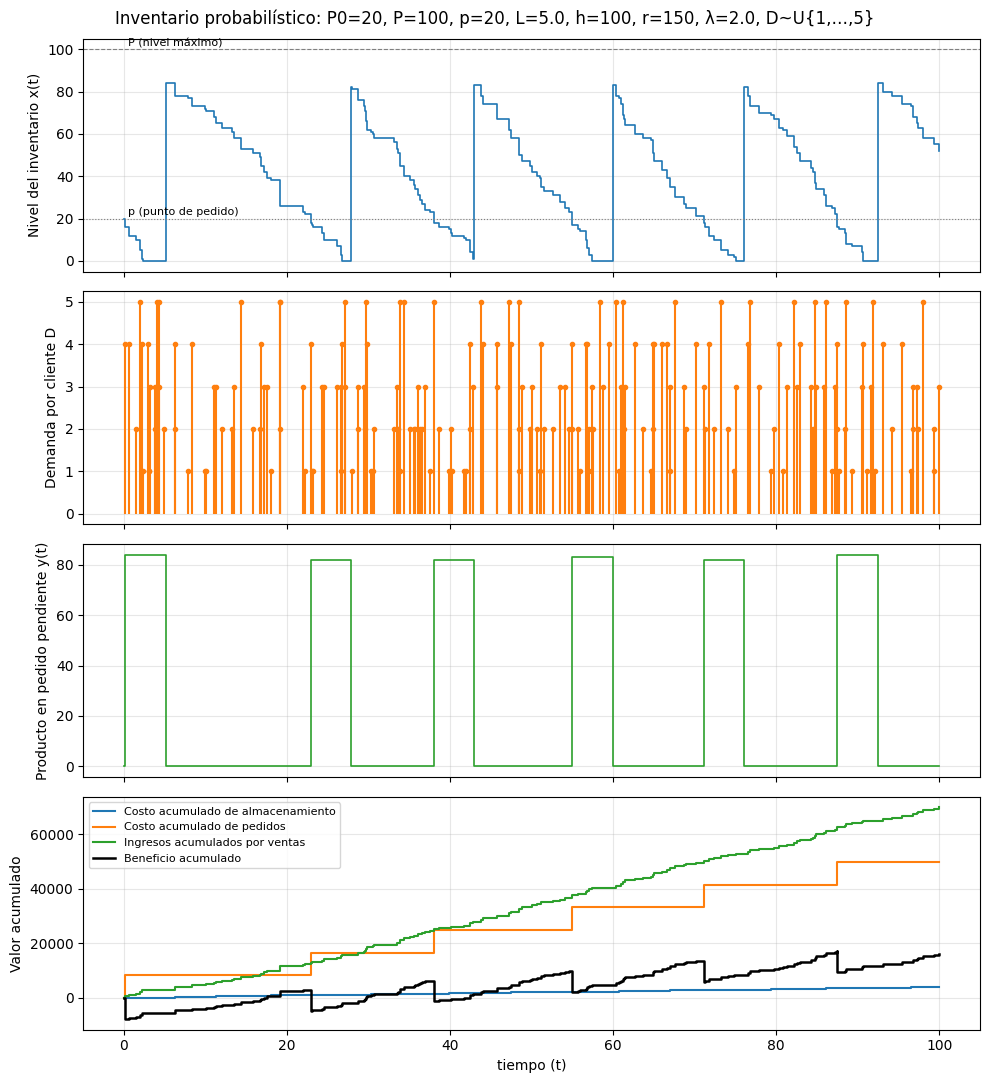

Uniformes consumidas: 377


In [3]:
g = GLC(2391)
res = simular_inventario(PARAM, g)
imprimir(res)
graficar(res, PARAM, 'inventario.png')
print("Uniformes consumidas:", g.consumidos)

### Repeticiones y sensibilidad al punto de pedido
Como una sola corrida es una estimación pobre, se repite 20 veces con semillas distintas y se resumen las
tres medidas de desempeño; además se explora cómo cambian al variar el punto de pedido $p$ con los demás
parámetros fijos.

20 repeticiones (beneficio, % satisfechos, % inventario en cero):
  Beneficio                media =     17642.80   desv. est. =    3151.83
  % clientes satisfechos   media =        84.61   desv. est. =       4.27
  % inventario en cero     media =        12.64   desv. est. =       3.65

Sensibilidad al punto de pedido p (medias de 20 repeticiones):
   p    Beneficio  % satisf.   % cero
  10     15547.44      78.40    18.87
  20     17642.80      84.61    12.64
  30     18921.57      90.82     7.55
  40     19252.24      95.15     3.72
  50     18875.25      96.83     2.45
  60     18402.52      97.11     2.24


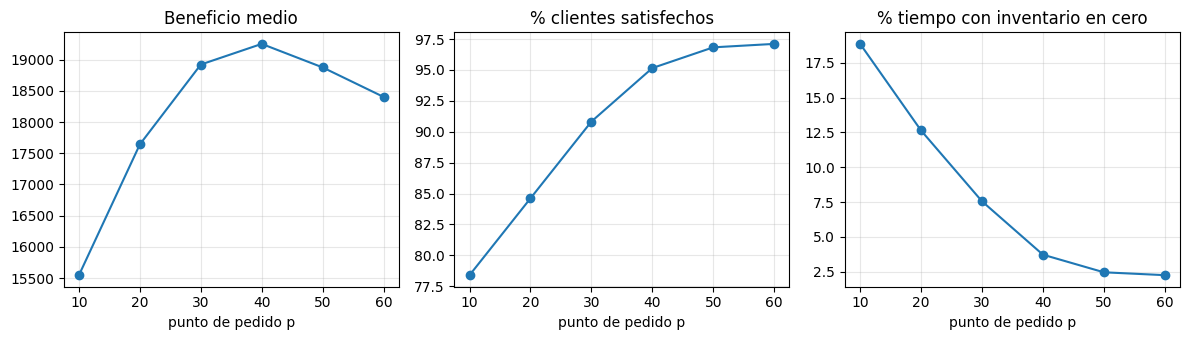

In [4]:
def repetir(par, n_rep, semilla_base=7001):
    filas = []
    for k in range(n_rep):
        r = simular_inventario(par, GLC(semilla_base + 7919 * k))
        filas.append([r['beneficio'], r['pct_satisfechos'], r['pct_cero']])
    return np.array(filas)

rep = repetir(PARAM, 20)
print("20 repeticiones (beneficio, % satisfechos, % inventario en cero):")
for nombre, col in zip(['Beneficio', '% clientes satisfechos', '% inventario en cero'], rep.T):
    print(f"  {nombre:24s} media = {col.mean():12.2f}   desv. est. = {col.std(ddof=1):10.2f}")

puntos = [10, 20, 30, 40, 50, 60]
sens = np.array([repetir({**PARAM, 'p': pp}, 20).mean(axis=0) for pp in puntos])
print("\nSensibilidad al punto de pedido p (medias de 20 repeticiones):")
print(f"{'p':>4s} {'Beneficio':>12s} {'% satisf.':>10s} {'% cero':>8s}")
for pp, fila in zip(puntos, sens):
    print(f"{pp:4d} {fila[0]:12.2f} {fila[1]:10.2f} {fila[2]:8.2f}")

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for a, j, et in zip(ax, range(3), ['Beneficio medio', '% clientes satisfechos', '% tiempo con inventario en cero']):
    a.plot(puntos, sens[:, j], 'o-'); a.set_xlabel('punto de pedido p'); a.set_title(et); a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig('inventario_sensibilidad.png', dpi=150, bbox_inches='tight'); plt.show()